In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Ukuran data:", df.shape)
print("\nNama fitur:")
print(df.columns)

Ukuran data: (20640, 9)

Nama fitur:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')


In [4]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


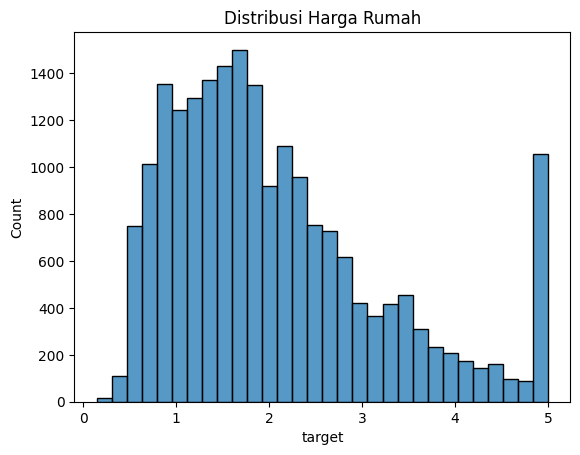

In [5]:
plt.figure()
sns.histplot(df["target"], bins=30)
plt.title("Distribusi Harga Rumah")
plt.show()

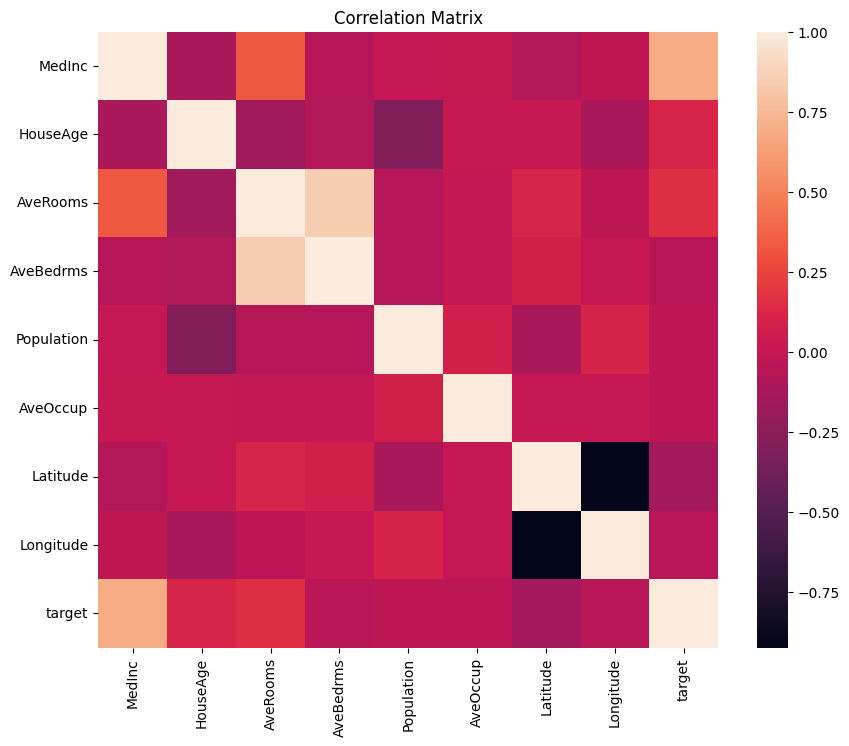

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Matrix")
plt.show()

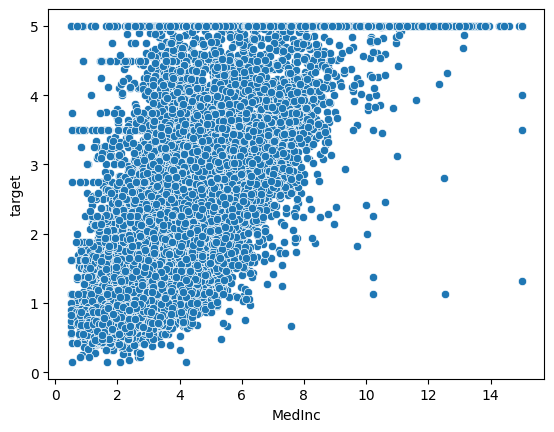

In [7]:
plt.figure()
sns.scatterplot(x="MedInc", y="target", data=df)
plt.show()

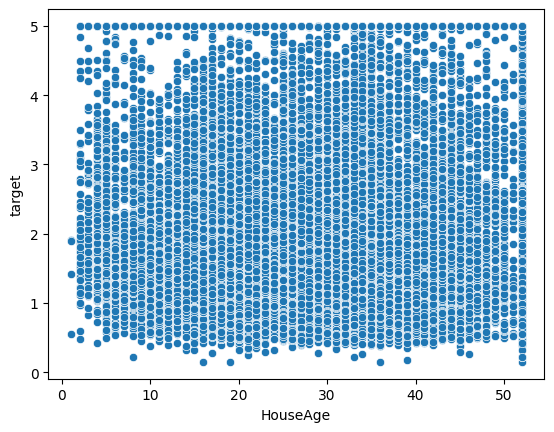

In [8]:
plt.figure()
sns.scatterplot(x="HouseAge", y="target", data=df)
plt.show()

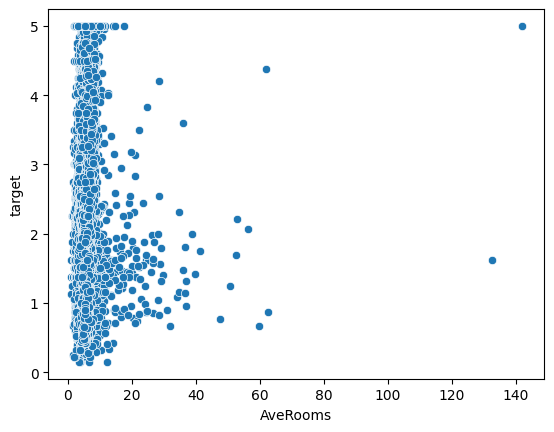

In [9]:
plt.figure()
sns.scatterplot(x="AveRooms", y="target", data=df)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

In [14]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.327425,0.505143,0.805275
2,Gradient Boosting,0.371650,0.542217,0.775643


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3,
                    scoring="r2")

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [16]:
import os

os.chdir("/content/drive/MyDrive/ml-practicum")
print(os.getcwd())

/content/drive/MyDrive/ml-practicum


In [18]:
!git pull origin main --rebase
!mkdir -p pertemuan-08
!git add .
!git commit -m "Add pertemuan 08 - MINI PROJECT REGRESSION - HOUSE PRICE PREDICTION"
!git push origin main

error: cannot pull with rebase: You have unstaged changes.
error: please commit or stash them.
[main 059ead1] Add pertemuan 08 - MINI PROJECT REGRESSION - HOUSE PRICE PREDICTION
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 pertemuan-08/105841102323_Agung Adi Rangga_Pertemuan-08.ipynb
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 329.29 KiB | 7.32 MiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
remote: This repository moved. Please use the new location:
remote:   https://github.com/Rangga-WebDev/learn-Machine.git
To https://github.com/Rangga-WebDev/learn-machine.git
   a12bd3a..059ead1  main -> main
